# Partial Fraction Expansion

A guided notebook on integrating **rational functions** $\dfrac{P(x)}{Q(x)}$ by breaking them into simpler fractions.

This notebook explains:
- when and why to use partial fractions
- polynomial division for **improper** rational functions
- the partial-fraction templates for each kind of denominator factor
- a full worked example combining $u$-substitution and trig substitution

This notebook follows the same style template as the uploaded guidelines, and builds on the earlier integration notebooks.

## 1. Introduction

Finding antiderivatives gets harder as integrands grow more elaborate. **Partial fraction expansion** is a technique for integrals of the form

$$
\int \frac{P(x)}{Q(x)}\,dx,
$$

where both $P$ and $Q$ are polynomials. The idea is to rewrite a complicated rational function as a **sum of simpler fractions**, each of which we already know how to integrate (usually via $u$-substitution or trigonometric substitution).

## 2. Proper vs. Improper Rational Functions

If the degree of $P$ is **greater than or equal to** the degree of $Q$, the fraction is *improper*, and we must first perform **polynomial division**:

$$
\frac{P(x)}{Q(x)} = C(x) + \frac{R(x)}{Q(x)},
$$

where $C$ and $R$ are polynomials and $\deg R < \deg Q$. The polynomial part $C(x)$ integrates directly, and the remaining **proper** fraction $\dfrac{R(x)}{Q(x)}$ is handled by partial fractions.

Once the fraction is proper:

1. **Factor** the denominator into linear and/or irreducible quadratic factors.
2. Write the fraction as a **sum of partial fractions**, one group per factor.
3. **Solve** for the unknown constants by comparison.
4. Integrate each simple piece.

## 3. The Partial-Fraction Templates

| Factor in denominator | Corresponding partial fraction(s) |
|-----------------------|-----------------------------------|
| $ax + b$ | $\dfrac{A}{ax+b}$ |
| $ax^2 + bx + c$ (irreducible) | $\dfrac{Ax + B}{ax^2 + bx + c}$ |
| $(ax + b)^n$ | $\dfrac{A_1}{ax+b} + \dfrac{A_2}{(ax+b)^2} + \cdots + \dfrac{A_n}{(ax+b)^n}$ |
| $(ax^2 + bx + c)^n$ | $\dfrac{A_1 x + B_1}{ax^2+bx+c} + \cdots + \dfrac{A_n x + B_n}{(ax^2+bx+c)^n}$ |

The constants $A, B, A_i, B_i$ are determined by comparison with the original expression. After expansion we are left with several much simpler integrals, usually with direct antiderivatives.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x', real=True)
A, B, C = sp.symbols('A B C')

## 4. Worked Example — Factoring the Denominator

Consider

$$
I = \int \frac{9x^2 + 3x - 2}{x^3 + 2x^2 - 2x + 3}\,dx.
$$

This is already **proper**: the denominator has degree 3 and the numerator degree 2. So we factor the denominator:

$$
x^3 + 2x^2 - 2x + 3 = (x + 3)(x^2 - x + 1),
$$

where $x^2 - x + 1$ is **irreducible** (its discriminant is $1 - 4 = -3 < 0$). Hence

$$
I = \int \frac{9x^2 + 3x - 2}{(x + 3)(x^2 - x + 1)}\,dx.
$$

In [2]:
denom = x**3 + 2*x**2 - 2*x + 3
print("factored denominator:", sp.factor(denom))
print("discriminant of x^2 - x + 1:", sp.discriminant(x**2 - x + 1, x), "(< 0 -> irreducible)")

factored denominator: (x + 3)*(x**2 - x + 1)
discriminant of x^2 - x + 1: -3 (< 0 -> irreducible)


## 5. Obtaining the Partial Fraction Expansion

Set up the expansion using the templates (a constant over the linear factor, a linear-over-quadratic for the irreducible factor):

$$
\frac{9x^2 + 3x - 2}{(x + 3)(x^2 - x + 1)} = \frac{A}{x + 3} + \frac{Bx + C}{x^2 - x + 1}.
$$

Multiply both sides by the denominator to clear fractions:

$$
9x^2 + 3x - 2 = A(x^2 - x + 1) + (Bx + C)(x + 3).
$$

Expanding the right-hand side and grouping by powers of $x$:

$$
9x^2 + 3x - 2 = (A + B)x^2 + (-A + 3B + C)x + (A + 3C).
$$

Matching coefficients gives a linear system:

$$
\begin{cases}
9 = A + B \\
3 = -A + 3B + C \\
-2 = A + 3C
\end{cases}
$$

Solving it yields

$$
A = \frac{70}{13}, \qquad B = \frac{47}{13}, \qquad C = -\frac{32}{13}.
$$

In [3]:
# Solve the coefficient system
solution = sp.solve([
    sp.Eq(A + B, 9),
    sp.Eq(-A + 3*B + C, 3),
    sp.Eq(A + 3*C, -2),
], [A, B, C])
print("system solution:", solution)

# Cross-check with SymPy's built-in apart()
frac = (9*x**2 + 3*x - 2) / ((x + 3)*(x**2 - x + 1))
print("apart():", sp.apart(frac, x))

system solution: {A: 70/13, B: 47/13, C: -32/13}
apart(): (47*x - 32)/(13*(x**2 - x + 1)) + 70/(13*(x + 3))


## 6. Finishing Off Using Previous Methods

With the constants known,

$$
I = \frac{70}{13}\int \frac{1}{x + 3}\,dx + \frac{47}{13}\int \frac{x}{x^2 - x + 1}\,dx - \frac{32}{13}\int \frac{1}{x^2 - x + 1}\,dx.
$$

### $I_1$ — a logarithm via $u$-substitution

With $u = x + 3$:

$$
I_1 = \frac{70}{13}\int \frac{1}{u}\,du = \frac{70}{13}\ln|x + 3| + C.
$$

### $I_2$ and $I_3$ — split the numerator to expose $u = x^2 - x + 1$

Note $\dfrac{d}{dx}(x^2 - x + 1) = 2x - 1$. Rewrite the middle numerator $x$ using $2x - 1$:

$$
\frac{47}{13}\int \frac{x}{x^2 - x + 1}\,dx - \frac{32}{13}\int \frac{1}{x^2 - x + 1}\,dx
= \frac{47}{26}\int \frac{2x - 1}{x^2 - x + 1}\,dx - \frac{17}{26}\int \frac{1}{x^2 - x + 1}\,dx.
$$

**$I_2$** (now a perfect $u'/u$) with $u = x^2 - x + 1$:

$$
I_2 = \frac{47}{26}\int \frac{2x - 1}{x^2 - x + 1}\,dx = \frac{47}{26}\ln|x^2 - x + 1| + C.
$$

**$I_3$** — complete the square, $x^2 - x + 1 = \left(x - \tfrac{1}{2}\right)^2 + \tfrac{3}{4}$, then use a tangent substitution:

$$
I_3 = -\frac{17}{26}\int \frac{1}{\left(x - \tfrac{1}{2}\right)^2 + \tfrac{3}{4}}\,dx
= -\frac{17\sqrt{3}}{39}\,\arctan\!\left(\frac{\sqrt{3}}{3}(2x - 1)\right) + C.
$$

### Putting it together

$$
\boxed{\;\int \frac{9x^2 + 3x - 2}{x^3 + 2x^2 - 2x + 3}\,dx = \frac{70}{13}\ln|x + 3| + \frac{47}{26}\ln|x^2 - x + 1| - \frac{17\sqrt{3}}{39}\arctan\!\left(\frac{\sqrt{3}}{3}(2x - 1)\right) + C\;}
$$

In [4]:
# Let SymPy integrate directly
I_sympy = sp.integrate((9*x**2 + 3*x - 2)/(x**3 + 2*x**2 - 2*x + 3), x)
print("SymPy result:")
sp.pprint(I_sympy)

# Our closed-form answer. We use plain log (not log|.|) so the symbolic
# derivative check simplifies cleanly; on the real domain d/dx ln(g) = g'/g
# matches the integrand regardless of the absolute-value bars.
ours = (sp.Rational(70, 13)*sp.log(x + 3)
        + sp.Rational(47, 26)*sp.log(x**2 - x + 1)
        - sp.Rational(17, 39)*sp.sqrt(3)*sp.atan(sp.sqrt(3)/3*(2*x - 1)))

# Verify by differentiating our answer and comparing to the integrand
integrand = (9*x**2 + 3*x - 2)/(x**3 + 2*x**2 - 2*x + 3)
check = sp.simplify(sp.diff(ours, x) - integrand)
print("\nd/dx(our answer) - integrand =", check, "  (0 means correct)")

SymPy result:
                                               ⎛2⋅√3⋅x   √3⎞
                      ⎛ 2        ⎞   17⋅√3⋅atan⎜────── - ──⎟
70⋅log(x + 3)   47⋅log⎝x  - x + 1⎠             ⎝  3      3 ⎠
───────────── + ────────────────── - ───────────────────────
     13                 26                     39           

d/dx(our answer) - integrand = 0   (0 means correct)


## 7. A Note on Improper Fractions

If the numerator's degree is **not** smaller than the denominator's, divide first. For instance,

$$
\frac{x^3}{x^2 - 1} = x + \frac{x}{x^2 - 1},
$$

so

$$
\int \frac{x^3}{x^2 - 1}\,dx = \int x\,dx + \int \frac{x}{x^2 - 1}\,dx = \frac{x^2}{2} + \frac{1}{2}\ln|x^2 - 1| + C.
$$

In [5]:
quotient, remainder = sp.div(x**3, x**2 - 1, x)
print("x^3 / (x^2 - 1):  quotient =", quotient, ", remainder =", remainder)
print("integral =", sp.integrate(x**3/(x**2 - 1), x), "+ C")

x^3 / (x^2 - 1):  quotient = x , remainder = x
integral = x**2/2 + log(x**2 - 1)/2 + C


## 8. Visual Check

An antiderivative's slope must equal the integrand. Below we plot the original integrand against the numerical slope of our closed-form antiderivative — they should overlap.

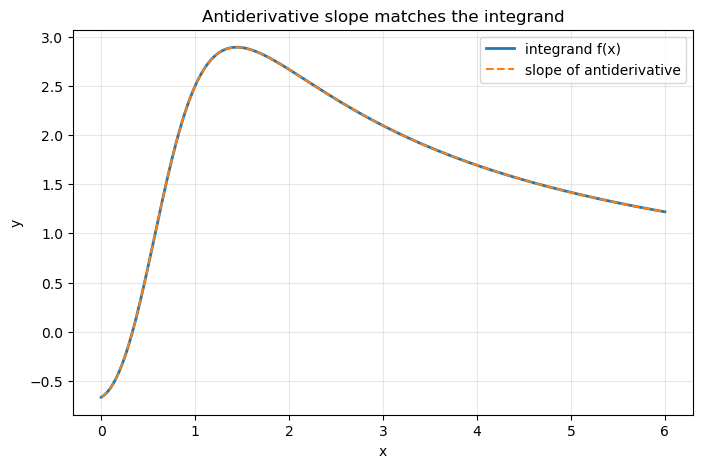

In [6]:
f = sp.lambdify(x, (9*x**2 + 3*x - 2)/(x**3 + 2*x**2 - 2*x + 3), 'numpy')
F = sp.lambdify(x, ours, 'numpy')

xv = np.linspace(0, 6, 400)   # stay away from the pole at x = -3
plt.figure(figsize=(8, 5))
plt.plot(xv, f(xv), label="integrand f(x)", linewidth=2)
plt.plot(xv, np.gradient(F(xv), xv), '--', label="slope of antiderivative")
plt.title("Antiderivative slope matches the integrand")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 9. Exercises

### Basic

1. Expand $\dfrac{1}{(x-1)(x+1)}$ into partial fractions, then compute $\displaystyle\int \frac{1}{(x-1)(x+1)}\,dx$.
2. Compute $\displaystyle\int \frac{5}{x^2 + 25}\,dx$.

### Intermediate

3. Compute $\displaystyle\int \frac{3x + 1}{x^2 + x - 2}\,dx$ (factor the denominator first).
4. Compute $\displaystyle\int \frac{x^2 + 1}{x - 1}\,dx$ (improper — divide first).

### Advanced

5. Compute $\displaystyle\int \frac{1}{x(x^2 + 1)}\,dx$ (linear $\times$ irreducible quadratic).
6. Compute $\displaystyle\int \frac{x}{(x + 1)^2}\,dx$ (repeated linear factor).

## 10. Solutions / Checks

**1.** $\dfrac{1}{(x-1)(x+1)} = \dfrac{1/2}{x-1} - \dfrac{1/2}{x+1}$, so the integral is $\dfrac{1}{2}\ln|x-1| - \dfrac{1}{2}\ln|x+1| + C$.

**2.** $\displaystyle\int \frac{5}{x^2 + 25}\,dx = \arctan\!\left(\frac{x}{5}\right) + C$ (since $\frac{5}{x^2+25} = \frac{5}{25}\cdot\frac{1}{(x/5)^2+1}$).

**3.** $x^2 + x - 2 = (x+2)(x-1)$; expansion $\dfrac{5/3}{x-1} + \dfrac{4/3}{x+2}$, giving $\dfrac{5}{3}\ln|x-1| + \dfrac{4}{3}\ln|x+2| + C$.

**4.** $\dfrac{x^2+1}{x-1} = x + 1 + \dfrac{2}{x-1}$, so the integral is $\dfrac{x^2}{2} + x + 2\ln|x-1| + C$.

**5.** $\dfrac{1}{x(x^2+1)} = \dfrac{1}{x} - \dfrac{x}{x^2+1}$, giving $\ln|x| - \dfrac{1}{2}\ln(x^2+1) + C$.

**6.** $\dfrac{x}{(x+1)^2} = \dfrac{1}{x+1} - \dfrac{1}{(x+1)^2}$, giving $\ln|x+1| + \dfrac{1}{x+1} + C$.

Run the cell below to verify these symbolically.

In [7]:
x = sp.symbols('x', real=True)

print("1. apart:", sp.apart(1/((x - 1)*(x + 1)), x))
print("   integral:", sp.integrate(1/((x - 1)*(x + 1)), x), "+ C")
print("2.", sp.integrate(5/(x**2 + 25), x), "+ C")
print("3. apart:", sp.apart((3*x + 1)/(x**2 + x - 2), x))
print("   integral:", sp.integrate((3*x + 1)/(x**2 + x - 2), x), "+ C")
print("4.", sp.integrate((x**2 + 1)/(x - 1), x), "+ C")
print("5. apart:", sp.apart(1/(x*(x**2 + 1)), x))
print("   integral:", sp.integrate(1/(x*(x**2 + 1)), x), "+ C")
print("6. apart:", sp.apart(x/(x + 1)**2, x))
print("   integral:", sp.integrate(x/(x + 1)**2, x), "+ C")

1. apart: -1/(2*(x + 1)) + 1/(2*(x - 1))
   integral: log(x - 1)/2 - log(x + 1)/2 + C


2. atan(x/5) + C
3. apart: 5/(3*(x + 2)) + 4/(3*(x - 1))
   integral: 4*log(x - 1)/3 + 5*log(x + 2)/3 + C
4. x**2/2 + x + 2*log(x - 1) + C
5. apart: -x/(x**2 + 1) + 1/x
   integral: log(x) - log(x**2 + 1)/2 + C
6. apart: 1/(x + 1) - 1/(x + 1)**2
   integral: log(x + 1) + 1/(x + 1) + C


## 11. Conclusion

In this topic we learned the **partial fraction expansion** integration method, summarized by

$$
\int \frac{P(x)}{Q(x)}\,dx = \int \frac{A}{ax + b}\,dx + \int \frac{Bx + C}{cx^2 + dx + e}\,dx + \cdots,
$$

where each summand on the right is solved with methods from previous topics — direct antiderivatives, $u$-substitution, and trigonometric substitution.

The workflow:

1. If improper, **divide** to get a polynomial plus a proper fraction.
2. **Factor** the denominator.
3. Write the **partial-fraction template** and solve for the constants.
4. **Integrate** each simple piece.

As with every integration method, mastery comes only with practice.

Key lesson:

$$
\text{a hard rational integral} \;\xrightarrow{\text{partial fractions}}\; \text{a sum of integrals you already know.}
$$